# Create Figures for paper

In [488]:
from plotnine import *
import pandas as pd

In [489]:
import matplotlib as mpl
from plotnine import theme_set, theme_bw

# Make Matplotlib and saved figures use white backgrounds
mpl.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "savefig.edgecolor": "white",
})

# Use a white plotnine theme globally
theme_set(theme_bw())


## Figure 1

In [490]:
fit_time_vs_loading_speed = pd.read_csv("source_data/fit_time_vs_loading_speed.csv", index_col=0)
fit_time_vs_loading_speed["model"] = fit_time_vs_loading_speed["model"].replace(
    {
        "linear": "linear model",
        "scVI hidden_dims=[128, 128]": "scVI (standard)",
        "scVI hidden_dims=[1024, 1024, 1024, 1024]": "scVI (big)"
    }
)
fit_time_vs_loading_speed.head()

,sleep,fit_time,samples_per_sec,model
0,40.000000,282.574075,818.394879,linear model
1,10.730783,76.596660,3050.836208,linear model
2,2.878743,21.613074,11370.062609,linear model
3,0.772279,6.849928,42373.243622,linear model
4,0.207179,2.848468,157832.826043,linear model


/Users/felix.fischer/opt/anaconda3/envs/annbatch/lib/python3.12/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/felix.fischer/opt/anaconda3/envs/annbatch/lib/python3.12/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: figures/figure1.svg


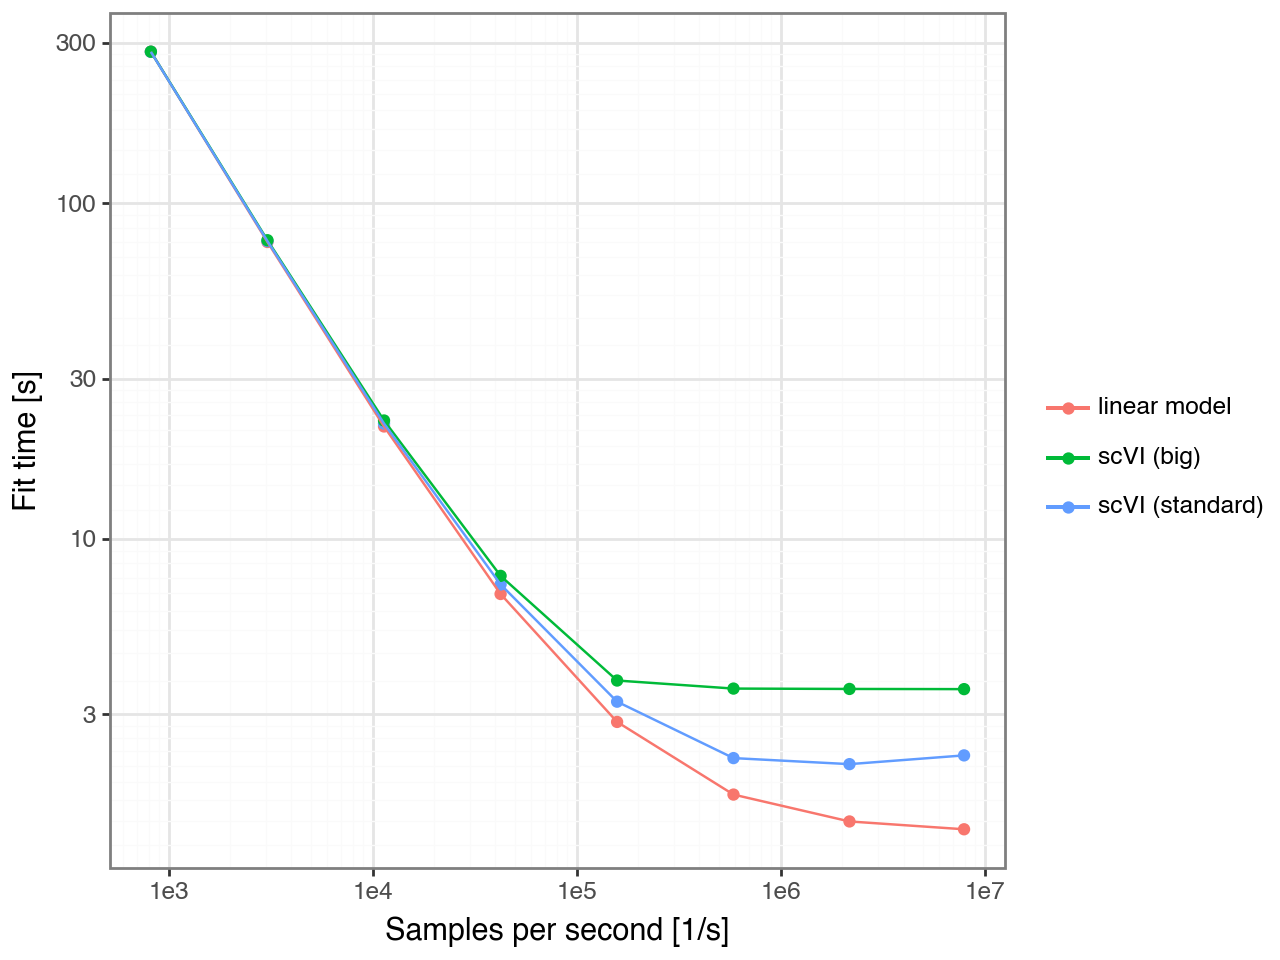

In [491]:
figure1 = (
    ggplot(fit_time_vs_loading_speed, aes(x="samples_per_sec", y="fit_time", color="model"))
    + geom_point()
    + geom_line()
    + scale_x_log10()
    + scale_y_log10()
    + xlab("Samples per second [1/s]")
    + ylab("Fit time [s]")
    + labs(color="")
    + theme(figure_size=(6.4, 4.8))
)

figure1.save("figures/figure1.svg")
figure1

## Figure 2

In [492]:
speed_comparision_aws = (
    pd.read_parquet("source_data/speed_comp_aws.parquet")
    .query("loader != 'scDataset (annbatch matched settings)' and loader != 'annbatch (chunk_size=64)'")
    .assign(
        loader_color=lambda x: x.loader.str.split(" ").str[0],
        loader=lambda x: x.loader.str.replace("scDataset (recommended settings)", "scDataset").str.replace(" ", "\n"),
        platform="AWS ml.m5.8xlarge",
    )
)

speed_comparision_denbi = (
    pd.read_csv("source_data/loading_times_full_epoch_2mio_samples_denbi.csv")
    .assign(
        loader=lambda x: x.loader.str.replace("AnnBatch", "annbatch"),
        loader_color=lambda x: x.loader.str.split(" ").str[0],
        platform="de.NBI",
    )
)

speed_comparision = pd.concat([speed_comparision_aws, speed_comparision_denbi], ignore_index=True)

speed_comp_plot = (
    ggplot(speed_comparision, aes(x="loader", y="samples/sec", fill="loader_color"))
    + geom_col(show_legend=False)
    + geom_text(aes(label="samples/sec"), va="bottom", angle=45, format_string="{:.0f}")
    + scale_fill_manual(values={"annbatch": "#00BA38", "MappedCollection": "#F8766D", "scDataset": "#619CFF"})
    + xlab("")
    + ylab("Samples per second [1/s]")
    + ylim(0, 75000)
    + facet_wrap("~platform", scales="free_x")
    + theme(axis_text_x=element_text(rotation=90, hjust=0.5))
    + labs(tag="a")
    + theme(plot_tag=element_text(fontweight="bold"))
)


In [493]:
time_per_epoch = pd.read_csv(
    "source_data/loading_times_full_epoch_fixed.csv"
).assign(
    total_time=lambda df: df.total_time / (60. * 60.),
    loader_color=lambda df: df.loader.str.split(" ").str[0],
    loader=lambda df: df.loader.str.replace(r'AnnBatch', 'annbatch', regex=True)
)
time_per_epoch_plot = (
    ggplot(time_per_epoch, aes(x="loader", y="total_time", fill="loader_color"))
    + geom_col(show_legend=False)
    + geom_text(aes(label="total_time"), va="bottom", format_string="{:.2f}")
    + scale_fill_manual(values={"annbatch": "#00BA38", "MappedCollection": "#F8766D", "scDataset": "#619CFF"})
    + xlab("")
    + ylab("Time per epoch [h]")
    + scale_x_discrete(limits=[
        'annbatch',
        'annbatch GPU',
        'MappedCollection',
        'scDataset'
    ])
    + ylim(0., 24.)
    + labs(tag="b")
    + theme(axis_text_x=element_text(rotation=90, hjust=0.5))
    + theme(plot_tag=element_text(fontweight='bold'))
)

In [494]:
image_benchmark = pd.read_csv("source_data/image_benchmark.csv")

image_benchmark_plot = (
    ggplot(image_benchmark, aes(x="loader", y="samples_per_sec", fill="loader"))
    + geom_col(show_legend=False)
    + geom_text(aes(label="samples_per_sec"), va="bottom", format_string="{:.0f}")
    + scale_fill_manual(values={"annbatch": "#00BA38", "scPortrait": "#F8766D"})
    + xlab("")
    + ylab("Samples per second [1/s]")
    + ylim(0, 15000)
    + labs(tag="c")
    + theme(axis_text_x=element_text(rotation=90, hjust=0.5))
    + theme(plot_tag=element_text(fontweight="bold"))
)


In [495]:
store_creation_time = pd.read_csv("source_data/store_creation_time.csv")
store_creation_time

,format,store_creation_time
0,zarr,6.724527
1,h5ad,15.242787


In [496]:
store_creation_time_plot = (
    ggplot(store_creation_time, aes(x="format", y="store_creation_time", fill="format"))
    + geom_col(show_legend=False)
    + xlab("")
    + ylab("Store creation time [h]")
    + labs(tag="d")
    + theme(plot_tag=element_text(fontweight='bold'))
)

In [497]:
chunked_loading_times = speed_comparision = (
    pd.read_parquet("source_data/speed_comp_aws.parquet")
    .query("loader in ['scDataset (annbatch matched settings)', 'annbatch (chunk_size=256)']")
    .assign(
        loader=lambda x: x.loader.replace({
            "scDataset (annbatch matched settings)": "h5ad (scDataset)",
            "annbatch (chunk_size=256)": "zarr (annbatch)"   
        })
    )
)
chunked_loading_times

,loader,samples/sec
2,zarr (annbatch),29921.343282
6,h5ad (scDataset),23048.011507


In [498]:
chunked_loading_times_plot = (
    ggplot(chunked_loading_times, aes(x="loader", y="samples/sec", fill="loader"))
    + geom_col(show_legend=False)
    + xlab("")
    + ylab("Samples per second [1/s]")
    + labs(tag="e")
    + theme(plot_tag=element_text(fontweight='bold'))
)

In [499]:
disk_usage = pd.DataFrame({
    "format": ["zarr", "h5ad"],
    "Disk usage [GB]": [325., 317.] 
})

disk_usage_plot = (
    ggplot(disk_usage, aes(x="format", y="Disk usage [GB]", fill="format"))
    + geom_col(show_legend=False)
    + ylim(0, 340)
    + xlab("")
    + labs(tag="f")
    + theme(plot_tag=element_text(fontweight='bold'))
)

In [500]:
process_scaling = pd.read_csv("source_data/parallel_loading_benchmark_results.csv")
process_scaling['loader'] = process_scaling['loader'].replace({
    'mapped_collection': 'MappedCollection'
})

# Group by loader and num_processes to calculate median and percentiles across repetitions
import numpy as np
process_scaling_grouped = process_scaling.groupby(['loader', 'num_processes'], as_index=False).agg({
    'cumulative_samples_per_sec': ['median', lambda x: np.percentile(x, 2.5), lambda x: np.percentile(x, 97.5)]
})
process_scaling_grouped.columns = ['loader', 'num_processes', 'cumulative_samples_per_sec', 'ci_lower', 'ci_upper']

# Create linear reference lines based on single-process performance
linear_reference = []
max_loading_speeds = []
for loader in process_scaling_grouped['loader'].unique():
    baseline = process_scaling_grouped[
        (process_scaling_grouped['loader'] == loader) &
        (process_scaling_grouped['num_processes'] == 1)
    ]['cumulative_samples_per_sec'].values[0]

    for num_proc in process_scaling_grouped['num_processes'].unique():
        linear_reference.append({
            'loader': loader,
            'num_processes': num_proc,
            'ideal_samples_per_sec': baseline * num_proc
        })

    # Get the loading speed at the highest number of processes
    max_num_processes = process_scaling_grouped['num_processes'].max()
    limit_speed = process_scaling_grouped[
        (process_scaling_grouped['loader'] == loader) &
        (process_scaling_grouped['num_processes'] == max_num_processes)
    ]['cumulative_samples_per_sec'].values[0]
    max_loading_speeds.append({
        'loader': loader,
        'max_speed': limit_speed
    })

linear_reference_df = pd.DataFrame(linear_reference)
max_loading_speeds_df = pd.DataFrame(max_loading_speeds)
max_loading_speeds_df

,loader,max_speed
0,MappedCollection,1869.181839
1,annbatch,137789.393595


In [501]:
process_scaling_plot = (
    ggplot(process_scaling_grouped, aes(x="num_processes", y="cumulative_samples_per_sec", color="loader"))
    + geom_hline(data=max_loading_speeds_df, mapping=aes(yintercept="max_speed", color="loader"),
                 linetype="dotted", alpha=0.7)
    + geom_point(data=linear_reference_df, mapping=aes(x="num_processes", y="ideal_samples_per_sec"),
                 alpha=0.5)
    + geom_line(data=linear_reference_df, mapping=aes(x="num_processes", y="ideal_samples_per_sec"),
                linetype="dashed", alpha=0.5)
    + geom_ribbon(aes(ymin="ci_lower", ymax="ci_upper", fill="loader"), alpha=0.2, color=None)
    + geom_point()
    + geom_line()
    + facet_wrap("~loader", scales="free_y")
    + scale_x_continuous(breaks=process_scaling_grouped.num_processes.unique())
    + xlab("Number of processes")
    + ylab("Cum. samples per second [1/s]")
    + labs(tag="g")
    + theme(plot_tag=element_text(fontweight='bold'), legend_position="none")
)

In [502]:
def round_to_nearest_50(x):
    return int(round(x / 50) * 50)

# Model info: each model has a list of label lines + a base speed
models = [
    {"lines": ["AIDO.Cell-3M", "(2k context len.)", "(BERT-style transformer)"], "speed": 1850},
    {"lines": ["AIDO.Cell-10M", "(2k context len.)", "(BERT-style transformer)"], "speed": 750},
    {"lines": ["ResNet-50 (224×224)"], "speed": 2000},
    {"lines": ["ViT (224×224)"], "speed": 1850},
    {"lines": ["DeepRVAT"], "speed": 14200},
]
col_x = {"Model": 0, "1 GPU": 6.96, "8 GPUs\n(95% eff.)": 9.49, "64 GPUs\n(80% eff.)": 12.02}
# Line spacing within model names (in y-units)
line_gap = 1.5
# Row centers (y positions for each model's numeric values)
row_y = [5, 10, 14, 17.5, 21]

# Build model name cells (one row per line, spread vertically around row center)
model_label_cells = []
for i, m in enumerate(models):
    n_lines = len(m["lines"])
    y_center = row_y[i]
    for j, line in enumerate(m["lines"]):
        y = y_center + (j - (n_lines - 1) / 2) * line_gap
        model_label_cells.append({"col": col_x["Model"], "row": y, "label": line})
model_labels_df = pd.DataFrame(model_label_cells)

# Build numeric value cells
num_cells = []
for i, m in enumerate(models):
    speed = m["speed"]
    gpu8 = round_to_nearest_50(speed * 8 * 0.95)
    gpu64 = round_to_nearest_50(speed * 64 * 0.80)
    num_cells.append({"col": col_x["1 GPU"], "row": row_y[i], "label": f"{speed:,}"})
    num_cells.append({"col": col_x["8 GPUs\n(95% eff.)"], "row": row_y[i], "label": f"{gpu8:,}"})
    if m["lines"][0] != "DeepRVAT":
        num_cells.append({"col": col_x["64 GPUs\n(80% eff.)"], "row": row_y[i], "label": f"{gpu64:,}"})
nums_df = pd.DataFrame(num_cells)

# Column headers for GPU counts
headers_nums = pd.DataFrame([
    {"col": col_x["1 GPU"], "row": 0.8, "label": "1 GPU"},
    {"col": col_x["8 GPUs\n(95% eff.)"], "row": 0.8, "label": "8 GPUs"},
    {"col": col_x["64 GPUs\n(80% eff.)"], "row": 0.8, "label": "64 GPUs"},
])

# Academic-style horizontal rules
hlines_df = pd.DataFrame({"y": [-2., 2.1, 23]})

table_plot = (
    ggplot()
    + geom_hline(data=hlines_df, mapping=aes(yintercept="y"), size=0.5)
    + geom_text(data=headers_nums, mapping=aes(x="col", y="row", label="label"),
                size=9, fontweight="bold", ha="center")
    + geom_text(data=model_labels_df, mapping=aes(x="col", y="row", label="label"),
                size=9, ha="left")
    + geom_text(data=nums_df, mapping=aes(x="col", y="row", label="label"),
                size=9, ha="center")
    + scale_y_reverse(expand=(0, 0))
    + scale_x_continuous(limits=(-0.5, 13.9))
    + xlab("Samples per second [1/s]")
    + ylab(" ")
    + labs(tag="h")
    + theme(
        axis_text=element_blank(),
        axis_ticks=element_blank(),
        axis_line=element_blank(),
        panel_grid=element_blank(),
        panel_background=element_blank(),
        panel_border=element_blank(),
        plot_background=element_rect(fill="white", color="white"),
        plot_tag=element_text(fontweight="bold"),
    )
)

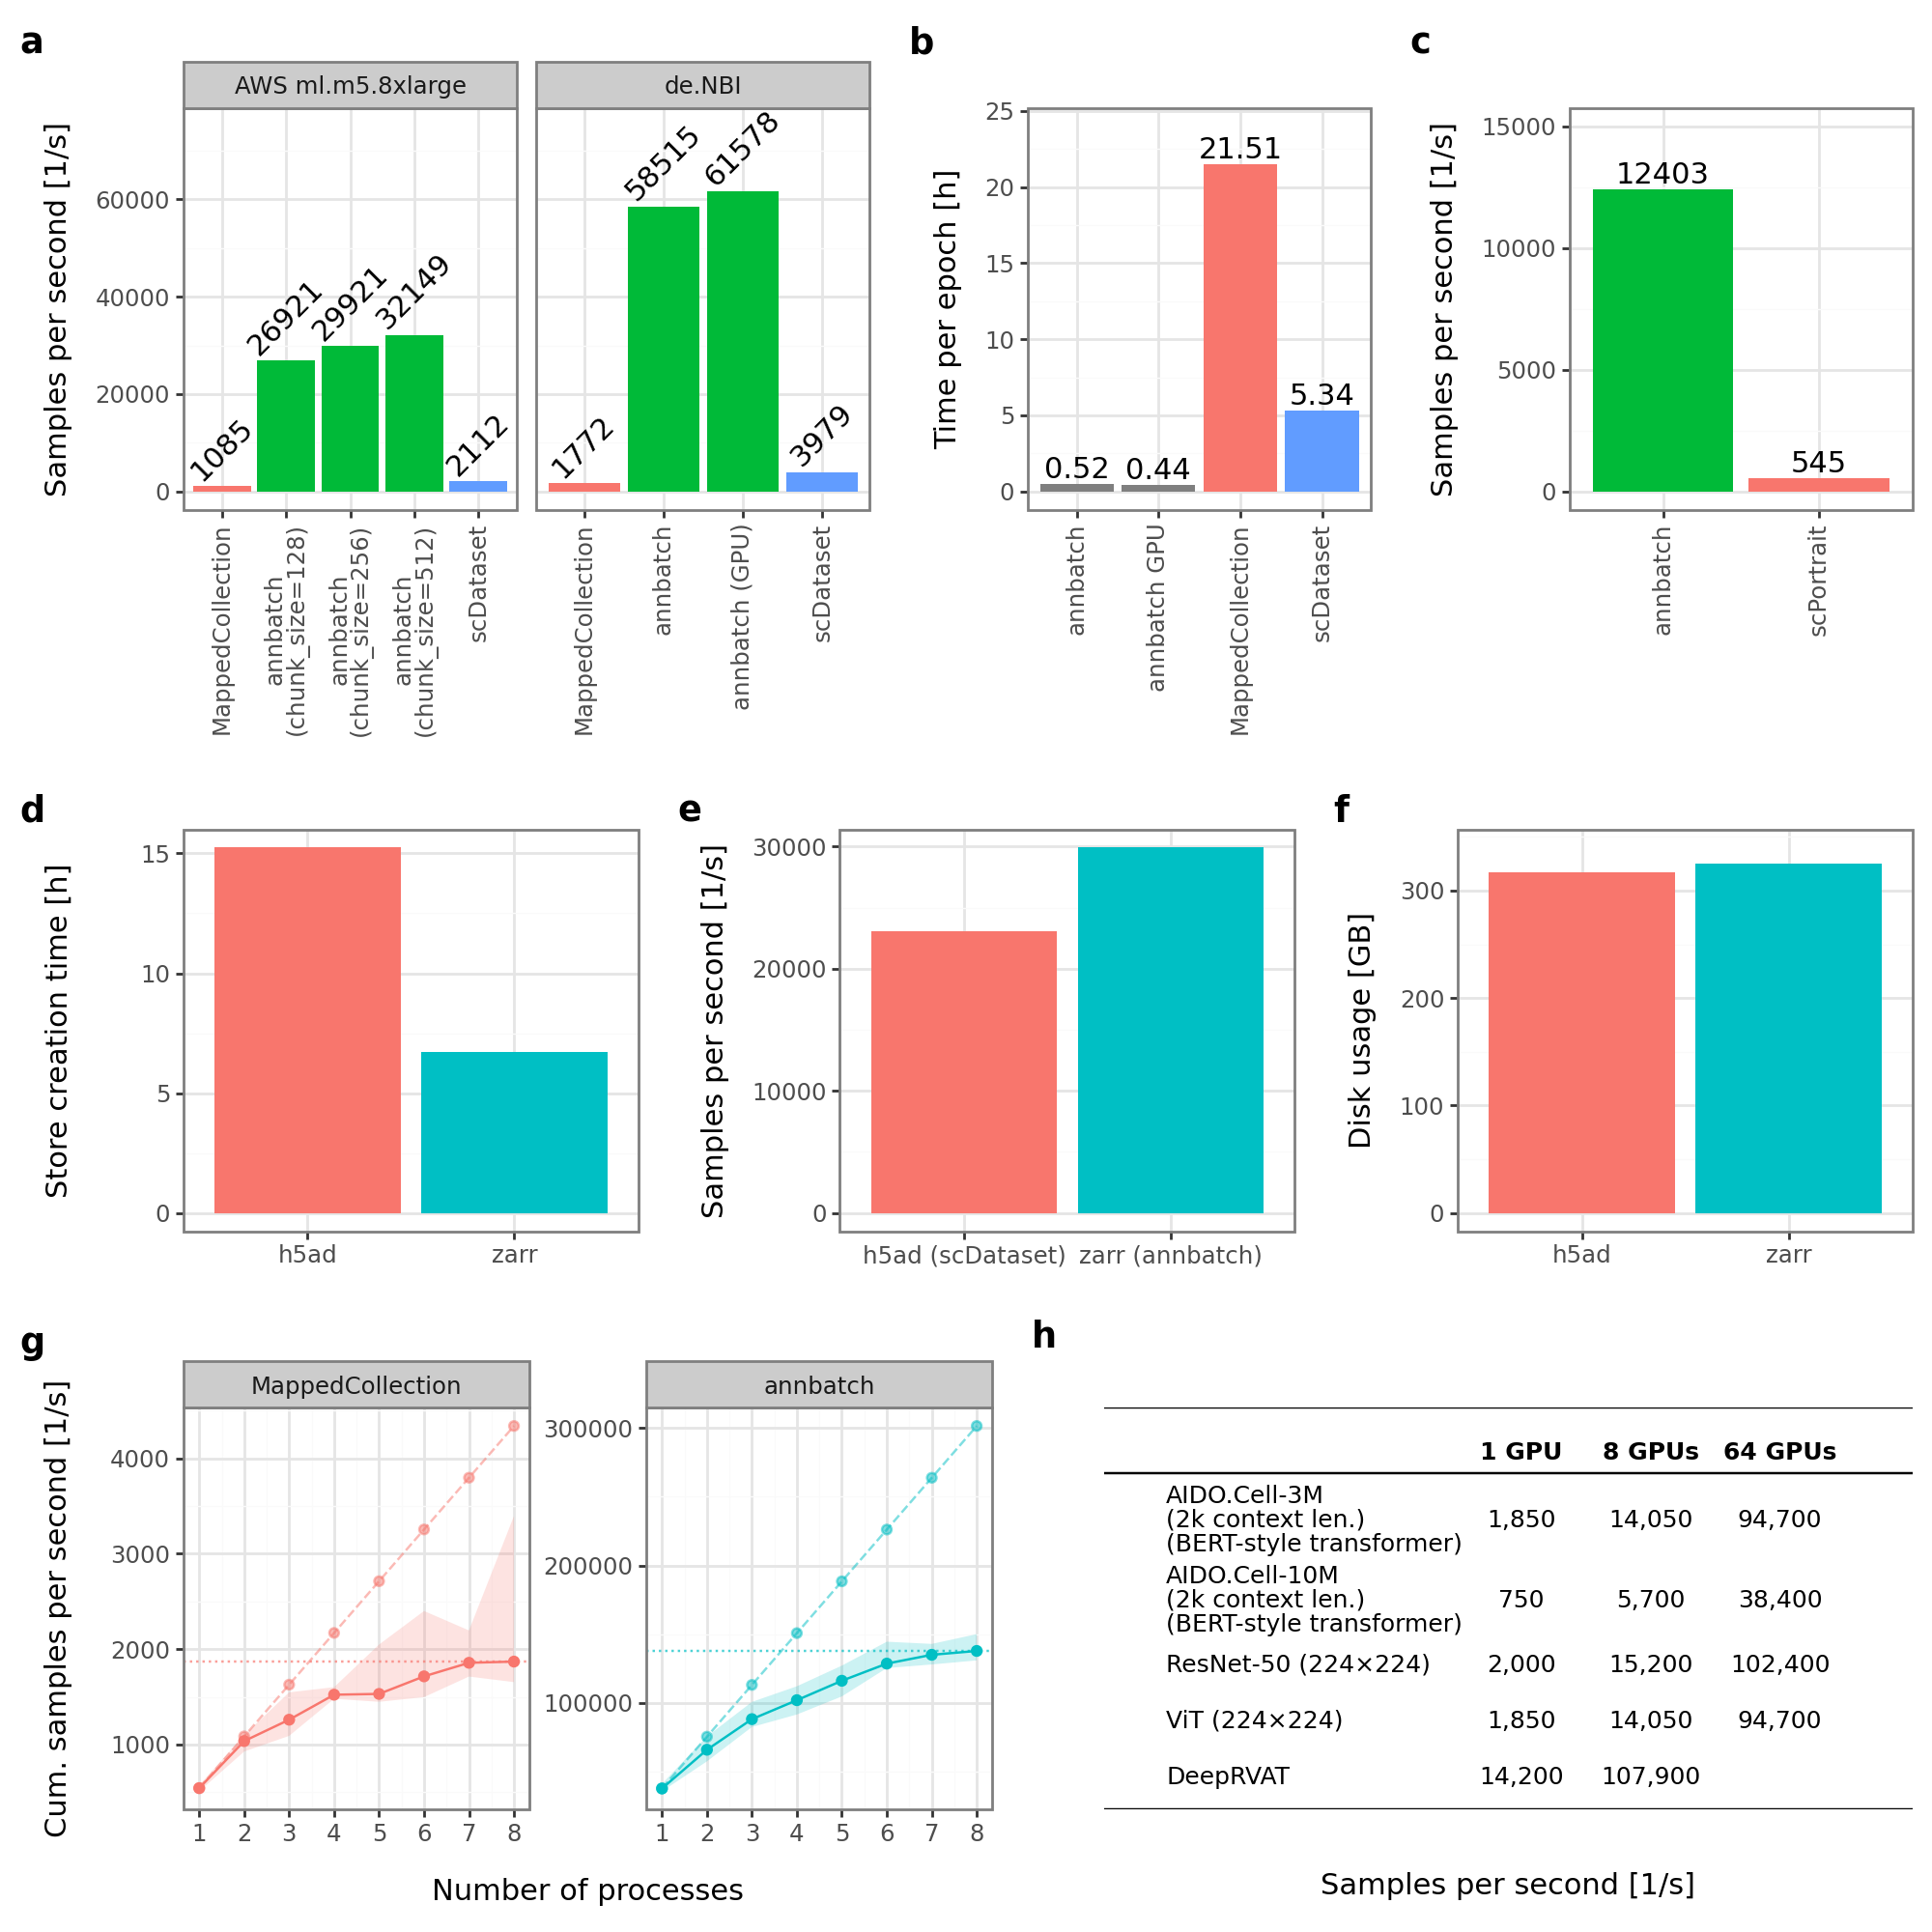

In [503]:
figure2 = (
    (speed_comp_plot | (time_per_epoch_plot | image_benchmark_plot)) /
    (store_creation_time_plot | chunked_loading_times_plot | disk_usage_plot) /
    (process_scaling_plot | table_plot)
) + theme(figure_size=(10, 10))
figure2


In [504]:
figure2.save("figures/figure2.svg")

## Supp. Fig. 1

In [505]:
batch_size_vs_fit_time = pd.read_csv("source_data/fit_time_vs_batch_size.csv", index_col=0)

batch_size_vs_fit_time_plot = (
    ggplot(batch_size_vs_fit_time, aes(x="batch_size", y="fit_time"))
    + geom_point()
    + geom_line()
    + scale_x_log10()
    + scale_y_log10()
    + xlab("Batch size")
    + ylab("Fit time [s]")
    + labs(color="")
    + labs(tag="a")
    + theme(plot_tag=element_text(fontweight='bold'), legend_position="none")
)

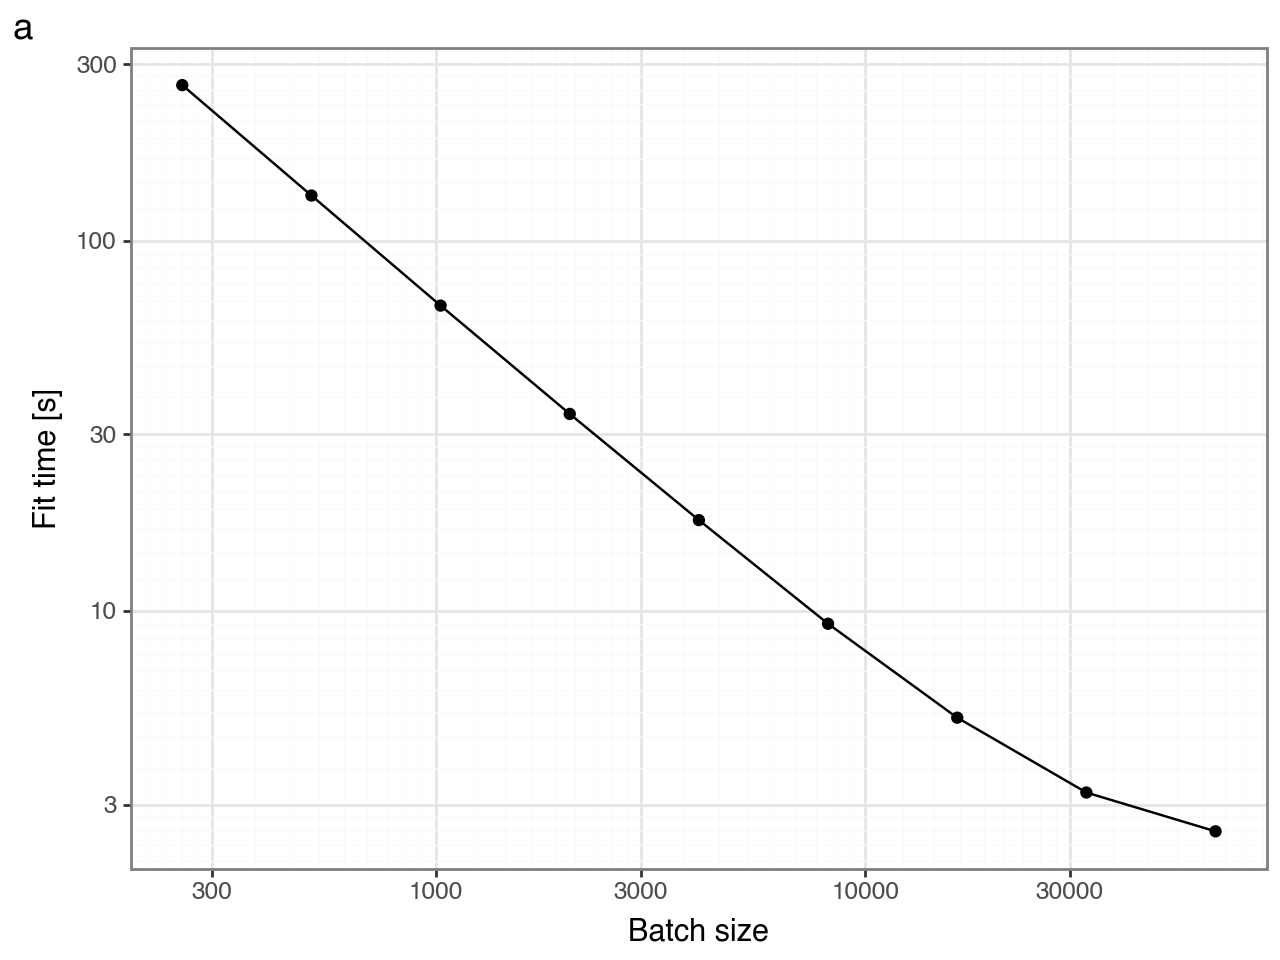

In [506]:
supp_fig1 = (
    batch_size_vs_fit_time_plot
)
supp_fig1

In [507]:
supp_fig1.save("figures/supp_fig1.svg")

/Users/felix.fischer/opt/anaconda3/envs/annbatch/lib/python3.12/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/felix.fischer/opt/anaconda3/envs/annbatch/lib/python3.12/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: figures/supp_fig1.svg
